# Question 1

## 1.1

### Algorithme

1. On commence en créant un réseau de spin selon 3 configurations de spins différentes: tous up, tous down et aléatoire

2. La condition périodique impose que lorsque dépasse une frontière, on se retrouve au départ. Par exemple, si 0<=i<=20, lorsqu'on passe à i=21, on doit retourner à i=0. Nous allons utiliser le modulo qui nous permet de ramener un i>L à un i<L.

3. On trouve le spin total des 4 voisins du spin qu'on choisit

### Code

In [2]:
import numpy as np
import matplotlib.pyplot as plt  


def spins_réseau(L,config):                                                                     #On définit une fonction qui prend la longueur et la configuration du réseau 
    if config == "up":
        return np.ones((L,L), dtype=int)                                                        #Si la configuration est "up", on retourne un réseau de spins tous à 1
    elif config == "down":
        return -np.ones((L,L), dtype=int)                                                       #Si la configuration est "down", on retourne un réseau de spins tous à -1
    elif config == "aléatoire": 
        return np.random.choice([-1, 1], size=(L, L))                                           #Si la configuration est "aléatoire", on retourne un réseau de spins aléatoires entre -1 et 1                             
    else:
        raise ValueError("Configuration non reconnue. Utilisez 'up', 'down' ou 'aléatoire'.")   #Si la configuration n'est pas reconnue, on lève une erreur
    
def voisin_spins(S,i,j):                                                                        #On définit une fonction qui prend le réseau de spins et les indices i et j, et retourne la somme des spins voisins en utilisant la périodicité du réseau
    L=S.shape[0]
    return (S[(i+1)%L,j]+
            S[(i-1)%L,j]+
            S[i,(j+1)%L]+
            S[i,(j-1)%L])                                                                     

## 1.2

### Algorithme

1. On calcule la différence d'énergie lorsqu'on inverse le spin donc E(-s) - E(s)

2. On code l'algorithme de Metropolis en choisissant comme condition que le nombre pigé est < exp(-dE/T) ou que dE soit plus petit ou égal à 0 parce que s'il est négatif, exp(-dE/T) est forcément plus grand que 1 et si l'exposant est nul, exp(0)=1 et la probabilité de piger un nombre < 1 est 100%


### Code

In [3]:

def diff_E(S,i,j,J,h):
    s=S[i,j]
    s_voisin=voisin_spins(S,i,j)                    #On définit une fonction qui prend le réseau de spins, les indices i et j, la constante d'échange J et le champ magnétique h, et retourne la différence d'énergie si on inverse le spin à la position (i,j)
    return 2*s*(J*s_voisin+h)

def Metropolis(S,T,J,h):
    L=S.shape[0]
    i=np.random.randint(0,L)                        #On définit une fonction qui prend le réseau de spins, la température T, la constante d'échange J et le champ magnétique h, et effectue une étape de l'algorithme de Metropolis
    j=np.random.randint(0,L)
    dE=diff_E(S,i,j,J,h)                            #On choisit un spin aléatoire et on calcule la différence d'énergie si on inverse ce spin
    if dE<=0 or np.random.rand()<np.exp(-dE/T):     #Si la différence d'énergie est négative ou si un nombre aléatoire est inférieur à exp(-dE/T), on inverse le spin
        S[i,j]*=-1
    else:                                           #Sinon, on ne fait rien
        pass

def Metropolis_simulation(L,T,J,h,config):
    N=L**2                                          #Nombre de spins dans le réseau                                                            
    S=spins_réseau(L,config)
    for _ in range(N):
        Metropolis(S,T,J,h)                         #On définit une fonction qui prend la longueur du réseau, la température, la constante d'échange, le champ magnétique, la configuration initiale et le nombre d'étapes de l'algorithme, et effectue la simulation de Metropolis
    return S


## 1.3

### Algorithme

1. On calcule l'aimantation instantanée qui est donnée par la somme des spins à un temps précis

2. L'énergie est donnée par la somme des énergies de chaque spin. On divise par deux pour éviter de compter deux la même liaison (La liaison ij est la même liaison que j-i).

### Code

In [4]:

def aimantation_instantanée(S):
    return np.sum(S)                               #On définit une fonction qui prend le réseau de spins et retourne l'aimantation instantanée en sommant tous les spins du réseau


def énergie(S,J,h):
    L=S.shape[0]
    E_inte=0.0
    E_champ=0.0
    for i in range(L):
        for j in range(L):
            s=S[i,j]
            s_voisin=voisin_spins(S,i,j)                                                        #On définit une fonction qui prend le réseau de spins, la constante d'échange J et le champ magnétique h, et retourne l'énergie totale du système en sommant les contributions de tous les spins et de leurs voisins
            E_inte+=-J*s*s_voisin
            E_champ+=-h*s
    return E_inte/2 + E_champ                                     #On divise par 2 pour éviter de compter chaque paire de spins deux fois 

### 1.3.1

#### Algorithme

1. On calcule la moyenne en faisant plusieurs itérations de l'évolution du spin

2. On calcule l'écart-type sur toutes les itérations

#### Code

In [5]:

def Metropolis(S,T,J,h):
    L=S.shape[0]
    i=np.random.randint(0,L)                    #On définit une fonction qui prend le réseau de spins, la température T, la constante d'échange J et le champ magnétique h, et effectue une étape de l'algorithme de Metropolis
    j=np.random.randint(0,L)
    dE=diff_E(S,i,j,J,h)
    s=S[i,j]                                    #On choisit un spin aléatoire et on calcule la différence d'énergie si on inverse ce spin
    if dE<=0 or np.random.rand()<np.exp(-dE/T): #Si la différence d'énergie est négative ou si un nombre aléatoire est inférieur à exp(-dE/T), on inverse le spin
        S[i,j]*=-1
        dM = -2*s                               #On calcule la différence d'aimantation si on inverse ce spin
        return dE, dM
    else:
        return 0, 0                                 #Si le spin n'est pas inversé, la différence d'énergie et d'aimantation est nulle


def Metropolis_simulation(S,T,J,h,n_it):
    L = S.shape[0]
    N=L**2                                           #Nombre de spins dans le réseau                                                            
    E_it=énergie(S,J,h)                       
    M_it=aimantation_instantanée(S)
    E_f=np.zeros(n_it+1)                             #On stocke l'énergie à chaque itération
    M_f=np.zeros(n_it+1)                             #On stocke l'aimantation à chaque itération
    E_f[0]=E_it
    M_f[0]=M_it                                           
    for n in range(1,n_it+1):
        for _ in range(N):
            dE, dM = Metropolis(S,T,J,h)
            E_it+=dE
            M_it+=dM 
        E_f[n]=E_it
        M_f[n]=M_it
    return S, E_f, M_f


def moyenne_ecart(A):
    A_moy=np.sum(A)/len(A)
    A2_moy=np.sum(A**2)/len(A)
    sA=np.sqrt(A2_moy-A_moy**2)
    return A_moy, sA

### 1.3.2

#### Algorithme

1. On calcule la susceptibilité

2. On définit une fonction qui va calculer la corrélation temporelle

#### Code

In [6]:


def susceptibilité(M,T,L):
    N=L**2
    M_moy, _ = moyenne_ecart(M)
    M2_moy, _ = moyenne_ecart(M**2)
    chi = (M2_moy - M_moy**2) / (N * T)
    return chi


def autocorrelation(x):
    x = np.asarray(x, dtype=float)
    n = len(x)
    chi = np.zeros(n)
    x_moy = np.mean(x)

    for t in range(n):
        a = x[:n-t]
        b = x[t:]
        chi[t] = np.mean((a-x_moy)*(b-x_moy))

    return chi/chi[0]

## 1.4

### Algorithme

On crée une fonction pour la règle de sélection de Glauber. C'est le même fonctionnement que pour Metropolis, mais on change le critère de sélection

### Code

In [7]:

def Glauber(S,T,J,h):
    L=S.shape[0]
    i=np.random.randint(0,L)                    #On définit une fonction qui prend le réseau de spins, la température T, la constante d'échange J et le champ magnétique h, et effectue une étape de l'algorithme de Glauber
    j=np.random.randint(0,L)
    dE=diff_E(S,i,j,J,h)                        #On choisit un spin aléatoire et on calcule la différence d'énergie si on inverse ce spin
    s=S[i,j]                                    #On choisit un spin aléatoire et on calcule la différence d'énergie si on inverse ce spin
    if np.random.rand()<1/(1+np.exp(dE/T)):     #Si un nombre aléatoire est inférieur à 1/(1+exp(dE/T)), on inverse le spin
        S[i,j]*=-1
        dM = -2*s                               #On calcule la différence d'aimantation si on inverse ce spin
        return dE, dM
    else:
        return 0, 0


def Glauber_simulation(S,T,J,h,n_it):
    L = S.shape[0]
    N=L**2                                       #Nombre de spins dans le réseau                                                            
    E_it=énergie(S,J,h)                       
    M_it=aimantation_instantanée(S)
    E_f=np.zeros(n_it+1)                         #On stocke l'énergie à chaque itération
    M_f=np.zeros(n_it+1)                         #On stocke l'aimantation à chaque itération
    E_f[0]=E_it
    M_f[0]=M_it
    for n in range(1,n_it+1):
        for _ in range(N):
            dE, dM = Glauber(S,T,J,h)
            E_it+=dE                             #On recalcule l'énergie après chaque étape de Glauber
            M_it+=dM                             #On recalcule l'aimantation après chaque étape de Glauber
        E_f[n]=E_it
        M_f[n]=M_it
    return S, E_f, M_f

## Rassemblement de tous les segments

### Algorithme

1. Selon la méthode choisie (Metropolis vs Glauber), on choisit un paramètre de sélection différent

2. On trouve le nombre de spin avec la longueur de la boite (N)

3. On crée le réseau de spin en fonction de la dimension de la boîte et de la configuration voulue (Tous up, tous down ou aléatoire)

4. On calcule l'énergie et l'aimantation initiale, qu'on ajoute à un tableau pour l'énergie et l'aimantation. Pour trouver l'énergie, nous trouvons l'énergie des 4 voisins.

5. Pour chaque itération, on lance N essais de changer le spin, et on calcule les variations d'énergie et d'aimantation

6. On ajoute l'énergie finale et l'aimantation finale dans les tableaux d'itérations

### Code

In [8]:
import numpy as np
from numba import njit #pour accélérer les fonctions avec Numba

    
def sim_Ising(L,T,J,h,config,n_it,selection):
    S = spins_réseau(L,config)
    if selection == "Metropolis":    
        S, E_f, M_f = Metropolis_simulation(S,T,J,h,n_it)
    elif selection == "Glauber":
        S, E_f, M_f = Glauber_simulation(S,T,J,h,n_it)
    else:
        raise ValueError("Sélection non reconnue. Utilisez 'Metropolis' ou 'Glauber'.")
    N=L**2
    autocor_E = autocorrelation(E_f/N)
    autocor_M = autocorrelation(M_f/N)
    return S, E_f, M_f, autocor_E, autocor_M

def spins_réseau(L,config):                                                                     #On définit une fonction qui prend la longueur et la configuration du réseau 
    if config == "up":
        return np.ones((L,L), dtype=np.int64)                                                   #Si la configuration est "up", on retourne un réseau de spins tous à 1
    elif config == "down":
        return -np.ones((L,L), dtype=np.int64)                                                  #Si la configuration est "down", on retourne un réseau de spins tous à -1
    elif config == "aléatoire": 
        return np.random.choice(np.array([-1, 1], dtype=np.int64), size=(L, L))                #Si la configuration est "aléatoire", on retourne un réseau de spins aléatoires entre -1 et 1                             
    else:
        raise ValueError("Configuration non reconnue. Utilisez 'up', 'down' ou 'aléatoire'.")  #Si la configuration n'est pas reconnue, on lève une erreur
    
@njit
def voisin_spins(S,i,j):                                                                        #On définit une fonction qui prend le réseau de spins et les indices i et j, et retourne la somme des spins voisins en utilisant la périodicité du réseau
    L=S.shape[0]
    return (S[(i+1)%L,j]+
            S[(i-1)%L,j]+
            S[i,(j+1)%L]+
            S[i,(j-1)%L])  
 
@njit
def diff_E(S,i,j,J,h):
    s=S[i,j]
    s_voisin=voisin_spins(S,i,j)                                                                #On définit une fonction qui prend le réseau de spins, les indices i et j, la constante d'échange J et le champ magnétique h, et retourne la différence d'énergie si on inverse le spin à la position (i,j)
    return 2*s*(J*s_voisin+h)

@njit
def Metropolis(S,T,J,h):
    L=S.shape[0]
    i=np.random.randint(0,L)                                                                    #On définit une fonction qui prend le réseau de spins, la température T, la constante d'échange J et le champ magnétique h, et effectue une étape de l'algorithme de Metropolis
    j=np.random.randint(0,L)
    dE=diff_E(S,i,j,J,h)
    s=S[i,j]                                                                                    #On choisit un spin aléatoire et on calcule la différence d'énergie si on inverse ce spin
    if dE<=0 or np.random.rand()<np.exp(-dE/T):                                                #Si la différence d'énergie est négative ou si un nombre aléatoire est inférieur à exp(-dE/T), on inverse le spin
        S[i,j]*=-1
        dM = -2*s                                                                               #On calcule la différence d'aimantation si on inverse ce spin
        return dE, dM
    else:
        return 0.0, 0                                                                           #Si le spin n'est pas inversé, la différence d'énergie et d'aimantation est nulle

@njit
def Metropolis_simulation(S,T,J,h,n_it):
    L = S.shape[0]
    N=L**2                                                                                      #Nombre de spins dans le réseau                                                            
    E_it=énergie(S,J,h)                       
    M_it=aimantation_instantanée(S)
    E_f=np.zeros(n_it+1)                                                                        #On stocke l'énergie à chaque itération
    M_f=np.zeros(n_it+1)                                                                        #On stocke l'aimantation à chaque itération
    E_f[0]=E_it
    M_f[0]=M_it                                                                                 #On stocke l'aimantation à chaque itération     
    for n in range(1,n_it+1):
        for _ in range(N):
            dE, dM = Metropolis(S,T,J,h)
            E_it+=dE
            M_it+=dM 
        E_f[n]=E_it
        M_f[n]=M_it
    return S, E_f, M_f

@njit
def Glauber(S,T,J,h):
    L=S.shape[0]
    i=np.random.randint(0,L)                                                                    #On définit une fonction qui prend le réseau de spins, la température T, la constante d'échange J et le champ magnétique h, et effectue une étape de l'algorithme de Glauber
    j=np.random.randint(0,L)
    dE=diff_E(S,i,j,J,h)                                                                        #On choisit un spin aléatoire et on calcule la différence d'énergie si on inverse ce spin
    s=S[i,j]                                                                                    #On choisit un spin aléatoire et on calcule la différence d'énergie si on inverse ce spin
    if np.random.rand()<1/(1+np.exp(dE/T)):                                                     #Si un nombre aléatoire est inférieur à 1/(1+exp(dE/T)), on inverse le spin
        S[i,j]*=-1
        dM = -2*s                                                                               #On calcule la différence d'aimantation si on inverse ce spin
        return dE, dM
    else:
        return 0.0, 0

@njit
def Glauber_simulation(S,T,J,h,n_it):
    L = S.shape[0]
    N=L**2                                                                                      #Nombre de spins dans le réseau                                                            
    E_it=énergie(S,J,h)                       
    M_it=aimantation_instantanée(S)
    E_f=np.zeros(n_it+1)                                                                        #On stocke l'énergie à chaque itération
    M_f=np.zeros(n_it+1)                                                                        #On stocke l'aimantation à chaque itération
    E_f[0]=E_it
    M_f[0]=M_it
    for n in range(1,n_it+1):
        for _ in range(N):
            dE, dM = Glauber(S,T,J,h)
            E_it+=dE                                                                            #On recalcule l'énergie après chaque étape de Glauber
            M_it+=dM                                                                            #On recalcule l'aimantation après chaque étape de Glauber
        E_f[n]=E_it
        M_f[n]=M_it
    return S, E_f, M_f

@njit
def aimantation_instantanée(S):
    return np.sum(S)                                                                            #On définit une fonction qui prend le réseau de spins et retourne l'aimantation instantanée en sommant tous les spins du réseau

@njit
def énergie(S,J,h):
    L=S.shape[0]
    E_inte=0.0
    E_champ=0.0
    for i in range(L):
        for j in range(L):
            s=S[i,j]
            s_voisin=voisin_spins(S,i,j)                                                        #On définit une fonction qui prend le réseau de spins, la constante d'échange J et le champ magnétique h, et retourne l'énergie totale du système en sommant les contributions de tous les spins et de leurs voisins
            E_inte+=-J*s*s_voisin
            E_champ+=-h*s
    return E_inte/2 + E_champ                                                                   #On divise par 2 pour éviter de compter chaque paire de spins deux fois  

def moyenne_ecart(A):
    A = np.asarray(A, dtype=np.float64)
    A_moy=np.sum(A)/len(A)
    A2_moy=np.sum(A**2)/len(A)
    sA=np.sqrt(A2_moy-A_moy**2)
    return A_moy, sA

def susceptibilité(M,T,L):
    N=L**2
    M_moy, _ = moyenne_ecart(M)
    M2_moy, _ = moyenne_ecart(M**2)
    chi = (M2_moy - M_moy**2) / (N * T)
    return chi

def autocorrelation(x):
    x = np.asarray(x, dtype=np.float64)
    n = len(x)
    chi = np.zeros(n)
    x_moy = np.mean(x)
    for t in range(n):
        a = x[:n-t]
        b = x[t:]
        chi[t] = np.mean((a-x_moy)*(b-x_moy))

    if chi[0] != 0:
        return chi/chi[0]
    else:
        return np.nan

# Question 2

## 2.1 et 2.2

### Tester l'énergie et l'aimantation

In [9]:
#Tester avec des paramètres très simples dont nous pouvons facilement calculer le résultat à la main

L=10
J=1
h=0

S_up=spins_réseau(L,"up")
print("Aimantation up : ", aimantation_instantanée(S_up))
print("Énergie up : ", énergie(S_up,J,h))

S_down=spins_réseau(L,"down")
print("Aimantation down : ", aimantation_instantanée(S_down))
print("Énergie down : ", énergie(S_down,J,h))

Aimantation up :  100
Énergie up :  -200.0
Aimantation down :  -100
Énergie down :  -200.0


### Tester à très basse température (Spin devrait changer très peu)

Autocorrélation de l'énergie (Metropolis) par spin:  nan
Autocorrélation de l'aimantation (Metropolis) par spin:  nan
Autocorrélation de l'énergie (Glauber) :  nan
Autocorrélation de l'aimantation (Glauber) :  nan


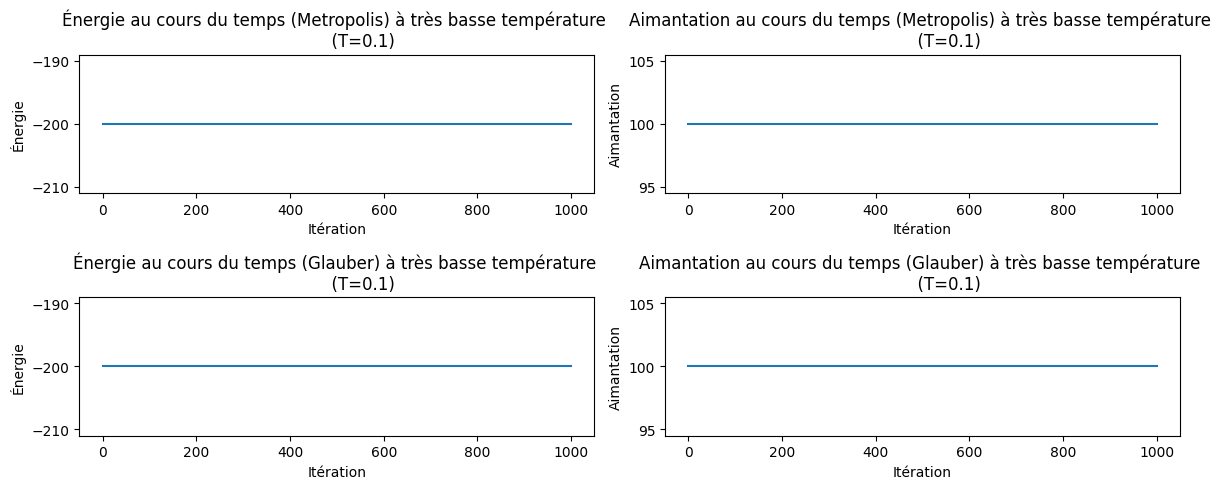

In [10]:

L=10
J=1
h=0
T=1e-1
config="up"
n_it=1000
méthode="Metropolis"
S, E_f, M_f, autocor_e, autocor_E = sim_Ising(L,T,J,h,config,n_it,méthode) #Les autocorrélations ne sont pas utilisées parce que la série est constante donc, nous aurons une division par zéro

print("Autocorrélation de l'énergie (Metropolis) par spin: ", autocor_e)
print("Autocorrélation de l'aimantation (Metropolis) par spin: ", autocor_e)
plt.figure(figsize=(12,5))

plt.subplot(2,2,1)
plt.plot(E_f)
plt.title(f"""Énergie au cours du temps (Metropolis) à très basse température 
          (T={T})""")
plt.xlabel("Itération")
plt.ylabel("Énergie")

plt.subplot(2,2,2)
plt.plot(M_f)
plt.title(f"""Aimantation au cours du temps (Metropolis) à très basse température 
          (T={T})""")
plt.xlabel("Itération")
plt.ylabel("Aimantation")

S, E_f, M_f, autocor_E, autocor_M  = sim_Ising(L,T,J,h,config,n_it,"Glauber")
print("Autocorrélation de l'énergie (Glauber) : ", autocor_E)
print("Autocorrélation de l'aimantation (Glauber) : ", autocor_M)

plt.subplot(2,2,3)
plt.plot(E_f)
plt.title(f"""Énergie au cours du temps (Glauber) à très basse température 
          (T={T})""")
plt.xlabel("Itération")
plt.ylabel("Énergie")

plt.subplot(2,2,4)
plt.plot(M_f)
plt.title(f"""Aimantation au cours du temps (Glauber) à très basse température 
          (T={T})""")
plt.xlabel("Itération")
plt.ylabel("Aimantation")

plt.tight_layout()
plt.show()

### Tester à très haute température (Beaucoup de variation de spin)

Autocorrélation de l'énergie (Metropolis) par spin:  [ 1.00000000e+00  8.87533531e-03 -8.23148677e-03 ...  1.75472763e+00
  9.32807689e+00 -3.36046971e+01]
Autocorrélation de l'aimantation (Metropolis) par spin:  [  1.           0.1869611    0.04957071 ...  -3.35323599 -11.81255272
  -0.12557711]
Autocorrélation de l'énergie (Glauber) par spin:  [ 1.00000000e+00  1.12619871e-01  7.23354184e-03 ... -1.99019676e+00
 -8.65621291e+00 -5.58792034e+00]
Autocorrélation de l'aimantation (Glauber) par spin:  [ 1.          0.39170195  0.12548769 ... -0.00970057 -0.3275849
 -4.84264145]


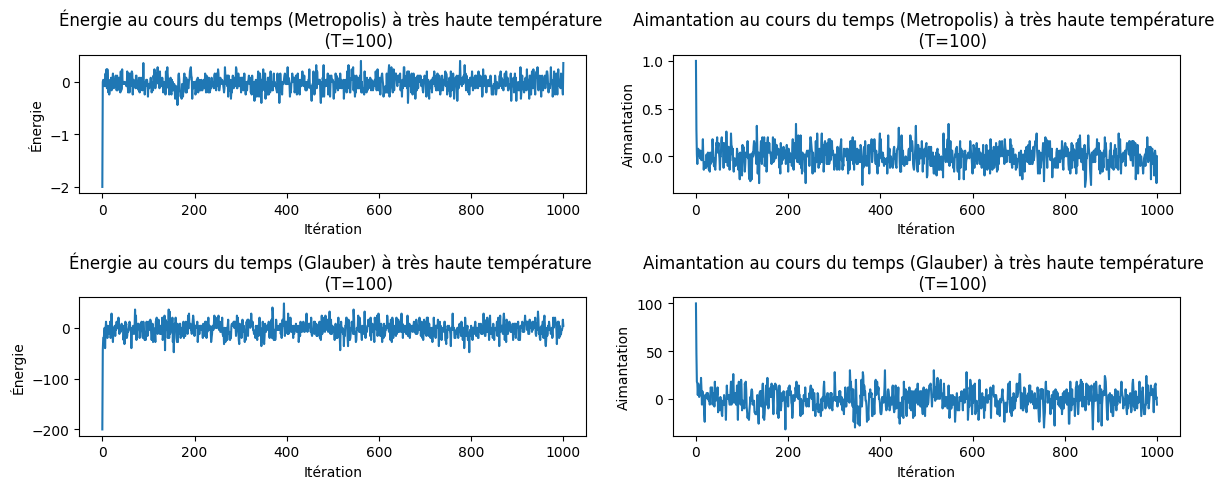

In [11]:
import matplotlib.pyplot as plt
L=10
J=1
h=0
T=100
config="up"
n_it=1000

S, E_f, M_f, autocor_e, autocor_m = sim_Ising(L,T,J,h,config,n_it,"Metropolis")
print("Autocorrélation de l'énergie (Metropolis) par spin: ", autocor_e)
print("Autocorrélation de l'aimantation (Metropolis) par spin: ", autocor_m)
plt.figure(figsize=(12,5))

plt.subplot(2,2,1)
plt.plot(E_f/L**2)
plt.title(f"""Énergie au cours du temps (Metropolis) à très haute température 
          (T={T})""")
plt.xlabel("Itération")
plt.ylabel("Énergie")

plt.subplot(2,2,2)
plt.plot(M_f/L**2)
plt.title(f"""Aimantation au cours du temps (Metropolis) à très haute température 
          (T={T})""")
plt.xlabel("Itération")
plt.ylabel("Aimantation")

S, E_f, M_f,autocor_e,autocor_m = sim_Ising(L,T,J,h,config,n_it,"Glauber")
print("Autocorrélation de l'énergie (Glauber) par spin: ", autocor_e)
print("Autocorrélation de l'aimantation (Glauber) par spin: ", autocor_m)

plt.subplot(2,2,3)
plt.plot(E_f)
plt.title(f"""Énergie au cours du temps (Glauber) à très haute température 
          (T={T})""")
plt.xlabel("Itération")
plt.ylabel("Énergie")

plt.subplot(2,2,4)
plt.plot(M_f)
plt.title(f"""Aimantation au cours du temps (Glauber) à très haute température 
          (T={T})""")
plt.xlabel("Itération")
plt.ylabel("Aimantation")

plt.tight_layout()
plt.show()

# Question 3

## 3.1

Température critique Tc = 2.2692

T = 1.00  (T < Tc (ordonnée))
  t_eq_E =    5 it.  |  E_eq/N = -1.9974 ± 0.0036
  t_eq_M =    5 it.  |  |M_eq|/N = 0.9993 ± 0.0009

T = 1.50  (T < Tc (ordonnée))
  t_eq_E =    9 it.  |  E_eq/N = -1.9513 ± 0.0171
  t_eq_M =   64 it.  |  |M_eq|/N = 0.9866 ± 0.0052

T = 2.50  (T > Tc (désordonnée))
  t_eq_E =   88 it.  |  E_eq/N = -1.1047 ± 0.0564
  t_eq_M =  200 it.  |  |M_eq|/N = 0.1139 ± 0.0846

T = 3.50  (T > Tc (désordonnée))
  t_eq_E =    7 it.  |  E_eq/N = -0.6561 ± 0.0425
  t_eq_M =   15 it.  |  |M_eq|/N = 0.0426 ± 0.0323



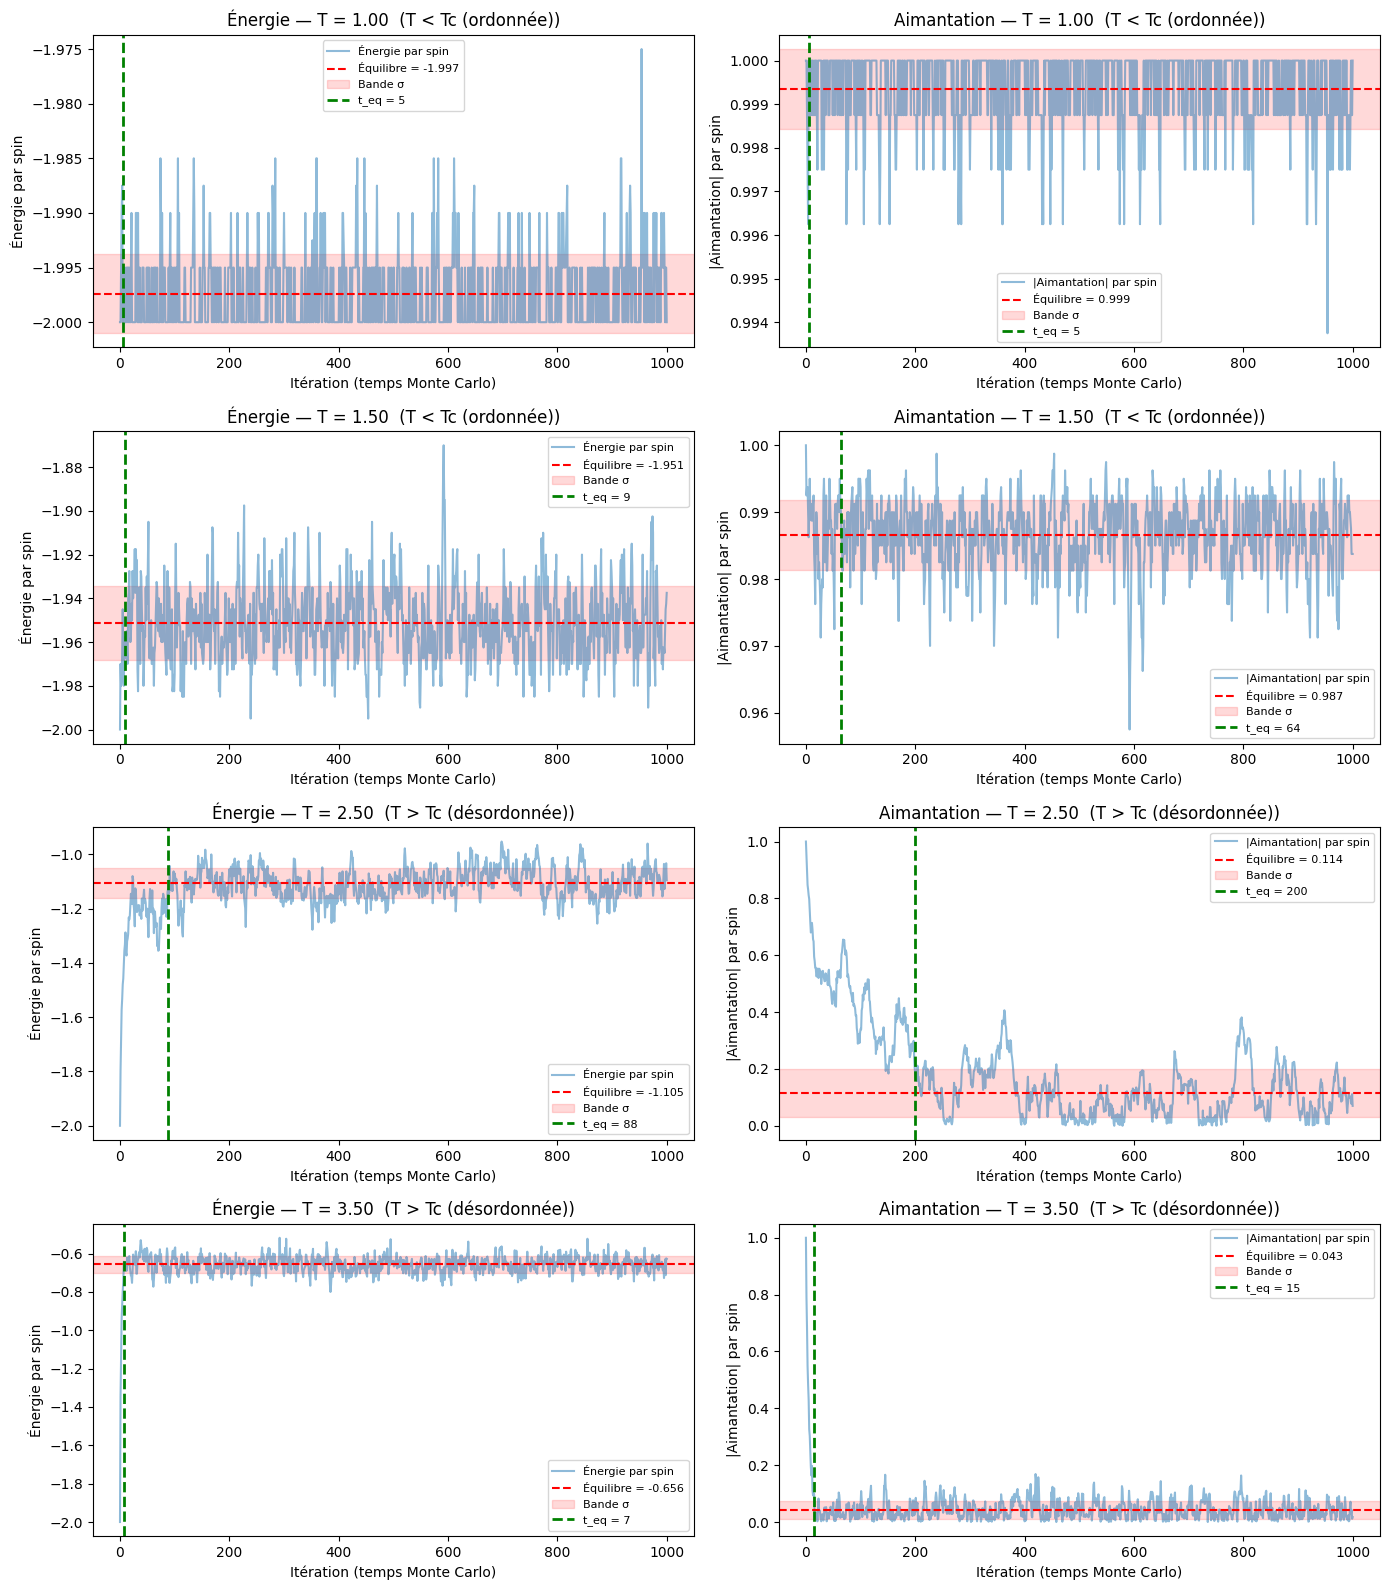

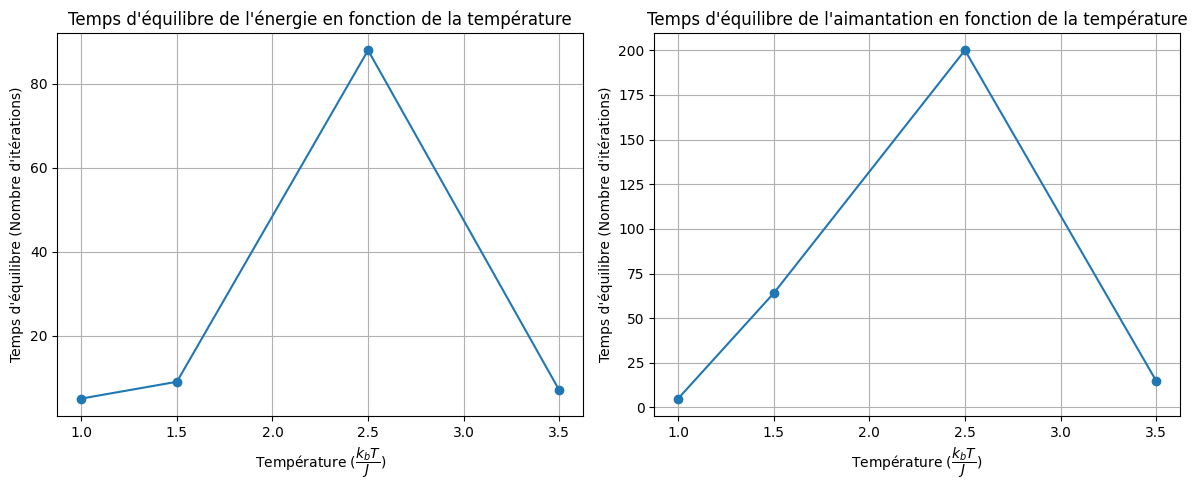

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def temps_equilibre(data, fraction_fin=0.3, largeur=3, persistance=10):

    data = np.asarray(data)
    n = len(data)

    if n < largeur:
        raise ValueError("La taille de la série doit être >= largeur.")

    debut_fin = int(n * (1 - fraction_fin))                     #On assume que les derniers points sont à l'équilibre et on utilise ces points pour estimer la valeur d'équilibre et l'écart-type
    partie_fin = data[debut_fin:]

    val_eq_est = np.mean(partie_fin)                            #On pose comme condition d'équilibre que la moyenne des dernières données est une bonne estimation de la valeur d'équilibre
    sigma_est = np.std(partie_fin)

    if sigma_est == 0:
        return debut_fin, val_eq_est, sigma_est

    noyau = np.ones(largeur) / largeur                          #Fonction qui permet de calculer la moyenne mobile sur une fenêtre de taille "largeur"

    moy_mobile = np.convolve(data, noyau, mode='valid')         #La convolution permet de calculer la moyenne sur une fenêtre glissante (dans mon cas, la moyenne de 5 points consécutifs). On crée une nouvelle fonction contenant les moyennes mobiles

    dans_bande = np.abs(moy_mobile - val_eq_est) < sigma_est    #On récupère tous les indices où la moyenne mobile est dans la bande de ±σ autour de l'estimation de l'équilibre

    t_eq = None
    compteur = 0

    for i, ok in enumerate(dans_bande):
        if ok:
            compteur += 1
            if compteur >= persistance:                          #Persistance est le nombre de points consécutifs que la moyenne mobile doit rester dans la bande pour considérer que l'équilibre est atteint
                t_eq = i - persistance + 1                       #On récupère l'indice de la première itération où la moyenne mobile est dans la bande depuis au moins "persistance" itérations
                break
        else:
            compteur = 0

    if t_eq is None:
        t_eq = 0

    t_eq = t_eq + largeur // 2                                    

    val_eq = np.mean(data[t_eq:])                                #On calcule moyenne sur toutes les données à l'équilibre
    sigma = np.std(data[t_eq:])

    return t_eq, val_eq, sigma


L = 40
J = 1
h = 0
Tc = 2 * J / np.log(1 + np.sqrt(2))     
n_it = 1000
config = "up"

# 2 températures avant Tc et 2 après Tc
temperatures = [1.0, 1.5, 2.5, 3.5]
temps_eq_E=[]
temps_eq_M=[]

Mean_E=[]
Mean_M=[]

sigE=[]
sigM=[]
print(f"Température critique Tc = {Tc:.4f}\n")

fig, axes = plt.subplots(len(temperatures), 2, figsize=(14, 4*len(temperatures)))

for idx, T in enumerate(temperatures):
    phase = "T < Tc (ordonnée)" if T < Tc else "T > Tc (désordonnée)"

    S, E_f, M_f,_,_ = sim_Ising(L, T, J, h, config, n_it, "Metropolis")

    N = L**2

    e_f = E_f / N
    m_f = M_f / N

    t_eq_E, E_eq, sigma_E = temps_equilibre(E_f)
    t_eq_M, M_eq, sigma_M = temps_equilibre(np.abs(M_f))
    
    temps_eq_E.append(t_eq_E)
    temps_eq_M.append(t_eq_M)
    Mean_E.append(E_eq/N)
    Mean_M.append(M_eq/N)
    sigE.append(sigma_E/N)
    sigM.append(sigma_M/N)

    print(f"T = {T:.2f}  ({phase})")
    print(f"  t_eq_E = {t_eq_E:4d} it.  |  E_eq/N = {Mean_E[idx]:.4f} ± {sigma_E/N:.4f}")
    print(f"  t_eq_M = {t_eq_M:4d} it.  |  |M_eq|/N = {M_eq/N:.4f} ± {sigma_M/N:.4f}")
    print()

    ax_E = axes[idx, 0]
    ax_E.plot(e_f, alpha=0.5, label="Énergie par spin")
    ax_E.axhline(Mean_E[idx], color='r', ls='--', label=f"Équilibre = {Mean_E[idx]:.3f}")
    ax_E.axhspan((E_eq - sigma_E)/N, (E_eq + sigma_E)/N, alpha=0.15, color='r', label="Bande σ")
    ax_E.axvline(t_eq_E, color='g', ls='--', lw=2, label=f"t_eq = {t_eq_E}")
    ax_E.set_xlabel("Itération (temps Monte Carlo)")
    ax_E.set_ylabel("Énergie par spin")
    ax_E.set_title(f"Énergie — T = {T:.2f}  ({phase})")
    ax_E.legend(fontsize=8)
    
    # --- Graphique Aimantation ---$
    ax_M = axes[idx, 1]
    ax_M.plot(np.abs(m_f), alpha=0.5, label="|Aimantation| par spin")
    ax_M.axhline(Mean_M[idx], color='r', ls='--', label=f"Équilibre = {Mean_M[idx]:.3f}")
    ax_M.axhspan((M_eq - sigma_M)/N, (M_eq + sigma_M)/N, alpha=0.15, color='r', label="Bande σ")
    ax_M.axvline(t_eq_M, color='g', ls='--', lw=2, label=f"t_eq = {t_eq_M}")
    ax_M.set_xlabel("Itération (temps Monte Carlo)")
    ax_M.set_ylabel("|Aimantation| par spin")
    ax_M.set_title(f"Aimantation — T = {T:.2f}  ({phase})")
    ax_M.legend(fontsize=8)
plt.tight_layout()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(temperatures, temps_eq_E, marker='o', label="t_eq Énergie")
plt.xlabel(r"Température ($\dfrac{k_bT}{J}$)")
plt.ylabel("Temps d'équilibre (Nombre d'itérations)")
plt.title("Temps d'équilibre de l'énergie en fonction de la température")
plt.grid(which='both')
plt.subplot(1,2,2)
plt.plot(temperatures, temps_eq_M, marker='o', label="t_eq Aimantation")
plt.xlabel(r"Température ($\dfrac{k_bT}{J}$)")
plt.ylabel("Temps d'équilibre (Nombre d'itérations)")
plt.title("Temps d'équilibre de l'aimantation en fonction de la température")
plt.grid(which='both')
plt.tight_layout()

plt.show()

## 3.2

Pour T = 1.0:
E = -3195.8474 ± 5.7729
M = 1598.9498 ± 1.4731
Variance de E : 33.3261
Variance de M : 2.1702

Pour T = 1.5:
E = -3122.1411 ± 27.3091
M = 1578.4803 ± 8.3802
Variance de E : 745.7865
Variance de M : 70.2283

Pour T = 2.5:
E = -1767.4918 ± 90.1861
M = 182.1623 ± 135.3948
Variance de E : 8133.5249
Variance de M : 18331.7539

Pour T = 3.5:
E = -1049.7344 ± 67.9304
M = 68.1278 ± 51.6399
Variance de E : 4614.5371
Variance de M : 2666.6814



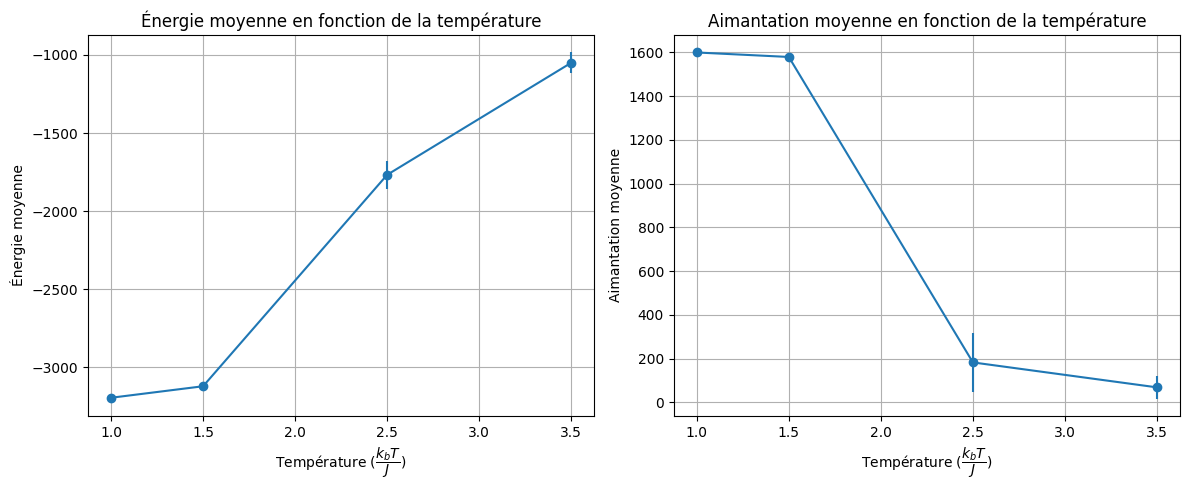

In [42]:
L = 20
J = 1
h = 0    
n_it = 1000
config = "up"

temperatures = [1.0, 1.5, 2.5, 3.5]
for i, T in enumerate(temperatures):

    print(f"Pour T = {T}:")
    print(f"E = {Mean_E[i]*N:.4f} ± {sigE[i]*N:.4f}")
    print(f"M = {Mean_M[i]*N:.4f} ± {sigM[i]*N:.4f}")
    print(f"Variance de E : {(sigE[i]**2*N**2):.4f}")
    print(f"Variance de M : {(sigM[i]**2*N**2):.4f}")
    print()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.errorbar(temperatures, np.array(Mean_E)*N, yerr=np.array(sigE)*N, marker='o', label="Énergie moyenne à l'équilibre")
plt.xlabel(r"Température ($\dfrac{k_bT}{J}$)")
plt.ylabel("Énergie moyenne")
plt.title("Énergie moyenne en fonction de la température")
plt.grid(which='both')
plt.subplot(1,2,2)
plt.errorbar(temperatures, np.array(Mean_M)*N, yerr=np.array(sigM)*N, marker='o', label="Aimantation moyenne à l'équilibre")
plt.xlabel(r"Température ($\dfrac{k_bT}{J}$)")
plt.ylabel("Aimantation moyenne")
plt.title("Aimantation moyenne en fonction de la température")
plt.grid(which='both')
plt.tight_layout()

## 3.3 et 3.4

Température critique théorique : Tc = 2.2692
Température critique estimée : Tc = 2.265 ± 0.015


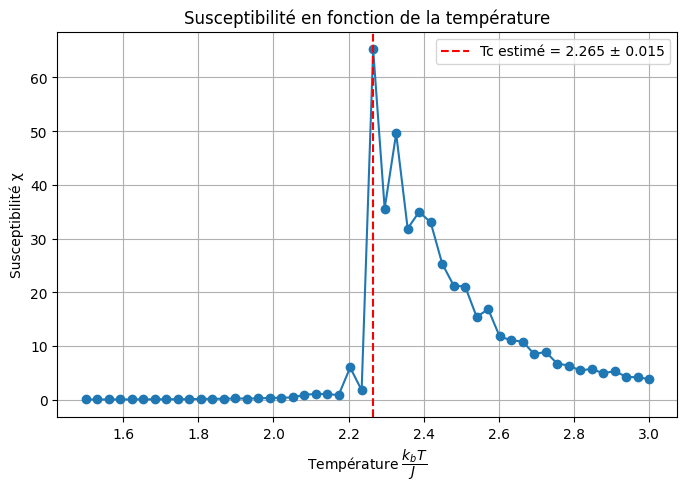

In [71]:
def susceptibilité(M,T,L):
    N=L**2
    M_moy, _ = moyenne_ecart(M)
    M2_moy, _ = moyenne_ecart(M**2)
    chi = (M2_moy - M_moy**2) / (N * T)
    return chi

L = 16
J = 1
h = 0    
n_it = 10000
config = "up"

Tc = 2 * J / np.log(1 + np.sqrt(2))


chi_val=[]
temperatures,h_T = np.linspace(1.5, 3, 50,retstep=True)  # 50 températures entre 1.5 et 3.0
for T in temperatures:
    _, _, M_f,_,_ = sim_Ising(L, T, J, h, config, n_it, "Glauber")
    t_eq_M, _, _ = temps_equilibre(M_f)
    chi = susceptibilité(M_f[t_eq_M:], T, L)
    chi_val.append(chi)

indice_max = np.argmax(chi_val)
Tc_est = temperatures[indice_max]
err_Tc = h_T / 2

print(f"Température critique théorique : Tc = {Tc:.4f}")

print(f"Température critique estimée : Tc = {Tc_est:.3f} ± {err_Tc:.3f}")
plt.figure(figsize=(8,5))
plt.plot(temperatures, chi_val, marker='o')
plt.axvline(Tc_est, color='r', ls='--', label=f"Tc estimé = {Tc_est:.3f} ± {err_Tc:.3f}")
plt.legend()
plt.xlabel(r"Température $\dfrac{k_bT}{J}$")
plt.ylabel("Susceptibilité χ")
plt.title("Susceptibilité en fonction de la température")
plt.grid()
plt.show()

## 3.5

Température critique Tc = 2.2692

T = 1.00  (T < Tc (ordonnée))
  t_eq_E =    1 it.  |  E_eq/N = -1.9972 ± 0.0074
  t_eq_M =    1 it.  |  |M_eq|/N = 0.9993 ± 0.0019

T = 1.50  (T < Tc (ordonnée))
  t_eq_E =   11 it.  |  E_eq/N = -1.9510 ± 0.0328
  t_eq_M =   10 it.  |  |M_eq|/N = 0.9863 ± 0.0102

T = 2.50  (T > Tc (désordonnée))
  t_eq_E =   32 it.  |  E_eq/N = -1.1351 ± 0.1364
  t_eq_M =   35 it.  |  |M_eq|/N = 0.3654 ± 0.2190

T = 3.50  (T > Tc (désordonnée))
  t_eq_E =   18 it.  |  E_eq/N = -0.6675 ± 0.0908
  t_eq_M =   17 it.  |  |M_eq|/N = 0.1046 ± 0.0769



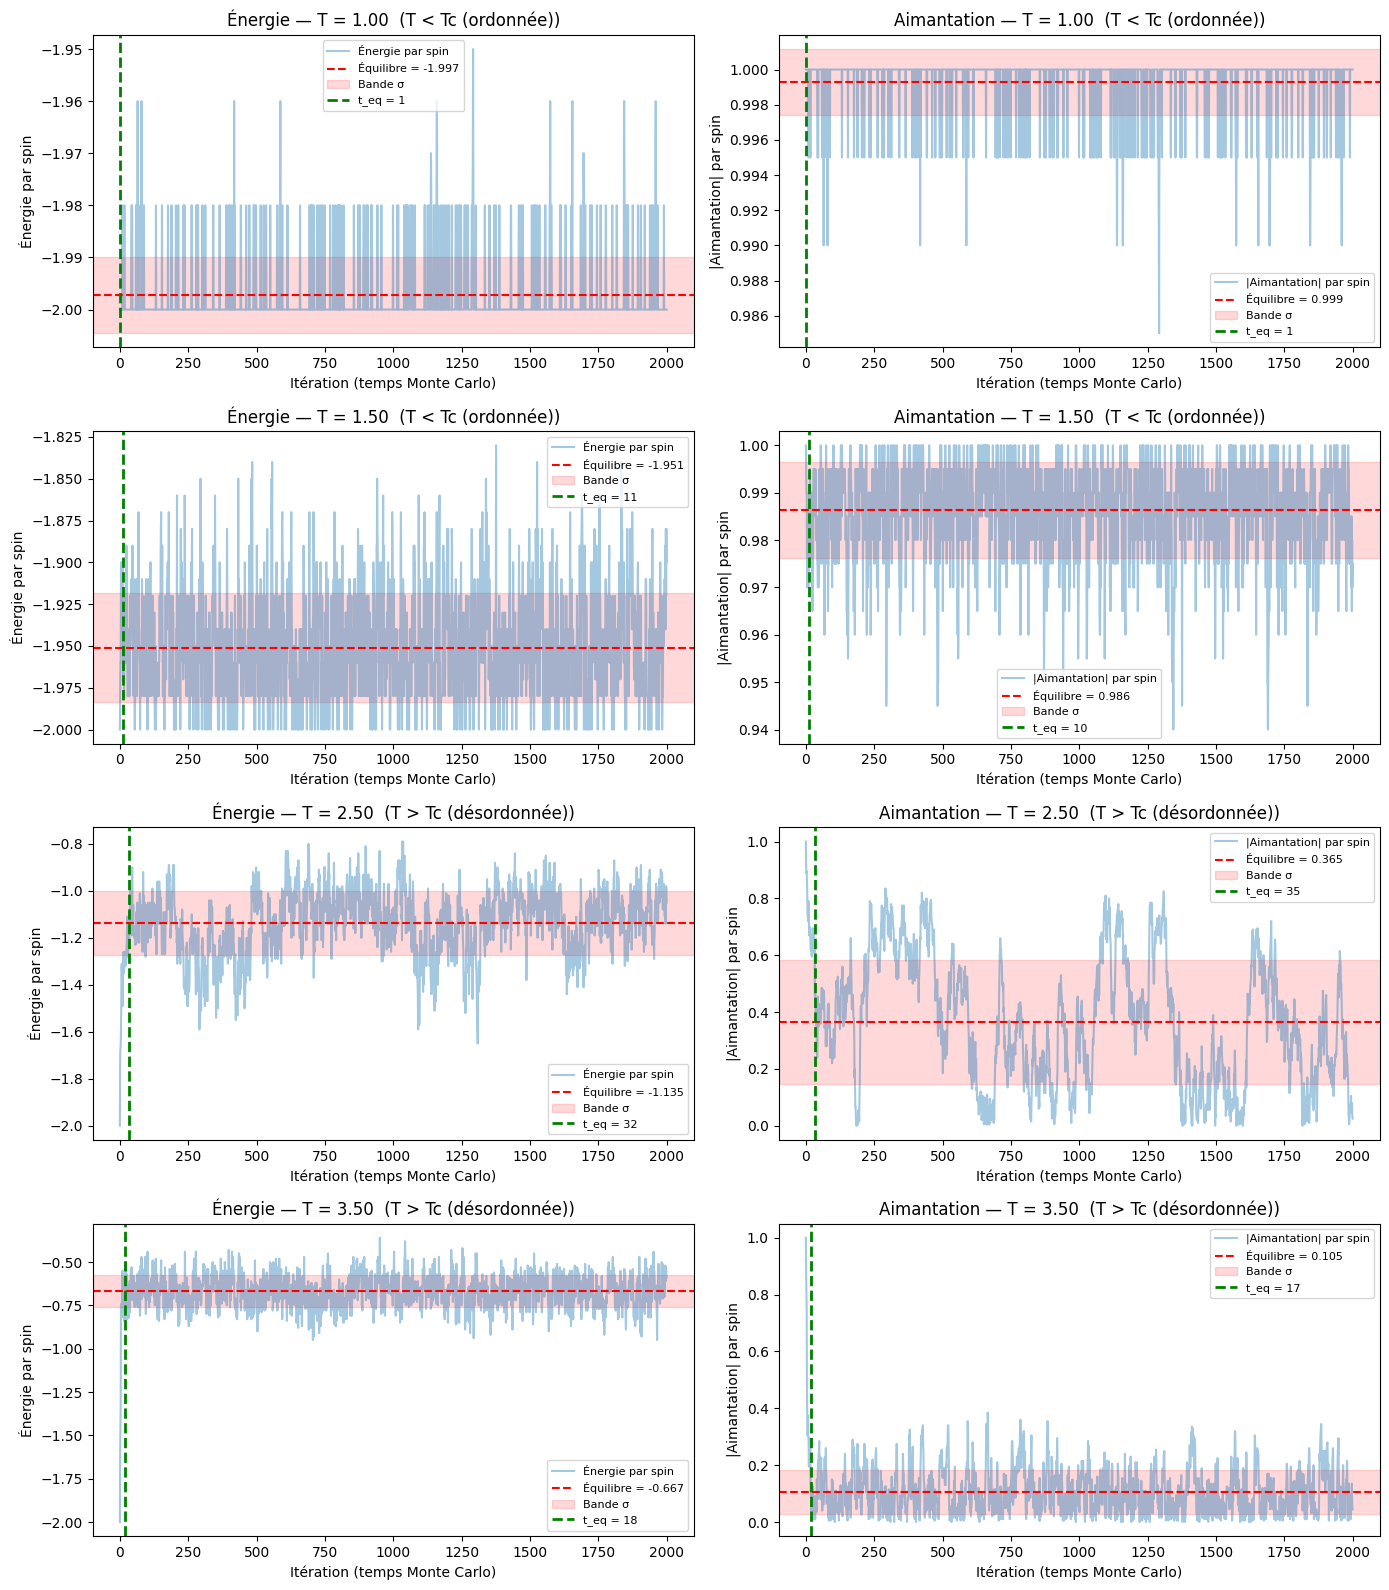

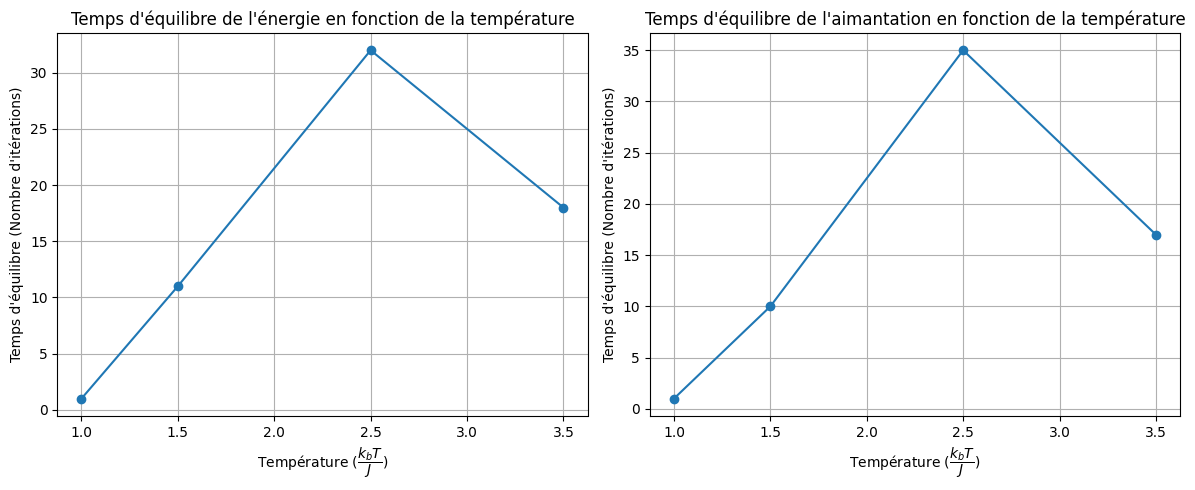

In [54]:


def temps_equilibre(data, fraction_fin=0.3, largeur=3, persistance=10):

    data = np.asarray(data)
    n = len(data)

    if n < largeur:
        raise ValueError("La taille de la série doit être >= largeur.")

    debut_fin = int(n * (1 - fraction_fin))                     #On assume que les derniers points sont à l'équilibre et on utilise ces points pour estimer la valeur d'équilibre et l'écart-type
    partie_fin = data[debut_fin:]

    val_eq_est = np.mean(partie_fin)                            #On pose comme condition d'équilibre que la moyenne des dernières données est une bonne estimation de la valeur d'équilibre
    sigma_est = np.std(partie_fin)

    if sigma_est == 0:
        return debut_fin, val_eq_est, sigma_est

    noyau = np.ones(largeur) / largeur                          #Fonction qui permet de calculer la moyenne mobile sur une fenêtre de taille "largeur"

    moy_mobile = np.convolve(data, noyau, mode='valid')         #La convolution permet de calculer la moyenne sur une fenêtre glissante (dans mon cas, la moyenne de 5 points consécutifs). On crée une nouvelle fonction contenant les moyennes mobiles

    dans_bande = np.abs(moy_mobile - val_eq_est) < sigma_est    #On récupère tous les indices où la moyenne mobile est dans la bande de ±σ autour de l'estimation de l'équilibre

    t_eq = None
    compteur = 0

    for i, ok in enumerate(dans_bande):
        if ok:
            compteur += 1
            if compteur >= persistance:                          #Persistance est le nombre de points consécutifs que la moyenne mobile doit rester dans la bande pour considérer que l'équilibre est atteint
                t_eq = i - persistance + 1                       #On récupère l'indice de la première itération où la moyenne mobile est dans la bande depuis au moins "persistance" itérations
                break
        else:
            compteur = 0

    if t_eq is None:
        t_eq = 0

    t_eq = t_eq + largeur // 2                                    

    val_eq = np.mean(data[t_eq:])
    sigma = np.std(data[t_eq:])

    return t_eq, val_eq, sigma


L = 20
J = 1
h = 0
Tc = 2 * J / np.log(1 + np.sqrt(2))     
n_it = 2000

config = "up"

# 2 températures avant Tc et 2 après Tc
temperatures = [1.0, 1.5, 2.5, 3.5]
temps_eq_E=[]
temps_eq_M=[]
print(f"Température critique Tc = {Tc:.4f}\n")

fig, axes = plt.subplots(len(temperatures), 2, figsize=(14, 4*len(temperatures)))

for idx, T in enumerate(temperatures):
    phase = "T < Tc (ordonnée)" if T < Tc else "T > Tc (désordonnée)"

    S, E_f, M_f,_,_ = sim_Ising(L, T, J, h, config, n_it, "Glauber")

    N = L**2

    e_f = E_f / N
    m_f = M_f / N

    t_eq_E, E_eq, sigma_E = temps_equilibre(E_f)
    t_eq_M, M_eq, sigma_M = temps_equilibre(np.abs(M_f))
    
    temps_eq_E.append(t_eq_E)
    temps_eq_M.append(t_eq_M)

    print(f"T = {T:.2f}  ({phase})")
    print(f"  t_eq_E = {t_eq_E:4d} it.  |  E_eq/N = {E_eq/N:.4f} ± {sigma_E/N:.4f}")
    print(f"  t_eq_M = {t_eq_M:4d} it.  |  |M_eq|/N = {M_eq/N:.4f} ± {sigma_M/N:.4f}")
    print()

    ax_E = axes[idx, 0]
    ax_E.plot(e_f, alpha=0.4, label="Énergie par spin")
    ax_E.axhline(E_eq/N, color='r', ls='--', label=f"Équilibre = {E_eq/N:.3f}")
    ax_E.axhspan((E_eq - sigma_E)/N, (E_eq + sigma_E)/N, alpha=0.15, color='r', label="Bande σ")
    ax_E.axvline(t_eq_E, color='g', ls='--', lw=2, label=f"t_eq = {t_eq_E}")
    ax_E.set_xlabel("Itération (temps Monte Carlo)")
    ax_E.set_ylabel("Énergie par spin")
    ax_E.set_title(f"Énergie — T = {T:.2f}  ({phase})")
    ax_E.legend(fontsize=8)
    
    # --- Graphique Aimantation ---
    ax_M = axes[idx, 1]
    ax_M.plot(np.abs(m_f), alpha=0.4, label="|Aimantation| par spin")
    ax_M.axhline(M_eq/N, color='r', ls='--', label=f"Équilibre = {M_eq/N:.3f}")
    ax_M.axhspan((M_eq - sigma_M)/N, (M_eq + sigma_M)/N, alpha=0.15, color='r', label="Bande σ")
    ax_M.axvline(t_eq_M, color='g', ls='--', lw=2, label=f"t_eq = {t_eq_M}")
    ax_M.set_xlabel("Itération (temps Monte Carlo)")
    ax_M.set_ylabel("|Aimantation| par spin")
    ax_M.set_title(f"Aimantation — T = {T:.2f}  ({phase})")
    ax_M.legend(fontsize=8)
plt.tight_layout()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(temperatures, temps_eq_E, marker='o', label="t_eq Énergie")
plt.xlabel(r"Température ($\dfrac{k_bT}{J}$)")
plt.ylabel("Temps d'équilibre (Nombre d'itérations)")
plt.title("Temps d'équilibre de l'énergie en fonction de la température")
plt.grid(which='both')
plt.subplot(1,2,2)
plt.plot(temperatures, temps_eq_M, marker='o', label="t_eq Aimantation")
plt.xlabel(r"Température ($\dfrac{k_bT}{J}$)")
plt.ylabel("Temps d'équilibre (Nombre d'itérations)")
plt.title("Temps d'équilibre de l'aimantation en fonction de la température")
plt.grid(which='both')
plt.tight_layout()

plt.show()

## 3.6

Température critique théorique : Tc = 2.2692
Température critique estimée : Tc = 2.939 ± 0.015


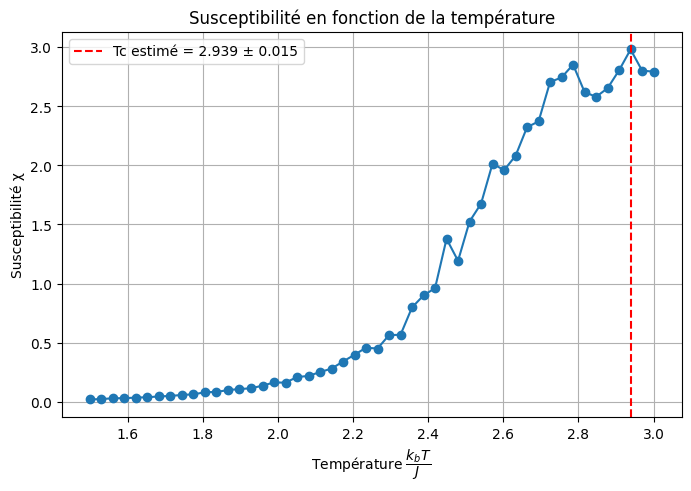

In [ ]:
def susceptibilité(M,T,L):
    N=L**2
    M_moy, _ = moyenne_ecart(M)
    M2_moy, _ = moyenne_ecart(M**2)
    chi = (M2_moy - M_moy**2) / (N * T)
    return chi

L = 16
J = 1
h = 0.1    
n_it = 10000
config = "up"

Tc = 2 * J / np.log(1 + np.sqrt(2))


chi_val=[]
temperatures,h_T = np.linspace(1.5, 3, 50,retstep=True)  # 50 températures entre 1.5 et 3.0
for T in temperatures:
    _, _, M_f,_,_ = sim_Ising(L, T, J, h, config, n_it, "Glauber")
    t_eq_M, _, _ = temps_equilibre(M_f)
    chi = susceptibilité(M_f[t_eq_M:], T, L)
    chi_val.append(chi)

indice_max = np.argmax(chi_val)
Tc_est = temperatures[indice_max]
err_Tc = h_T / 2

print(f"Température critique théorique : Tc = {Tc:.4f}")

print(f"Température critique estimée : Tc = {Tc_est:.3f} ± {err_Tc:.3f}")
plt.figure(figsize=(8,5))
plt.plot(temperatures, chi_val, marker='o')
plt.axvline(Tc_est, color='r', ls='--', label=f"Tc estimé = {Tc_est:.3f} ± {err_Tc:.3f}")
plt.legend()
plt.xlabel(r"Température $\dfrac{k_bT}{J}$")
plt.ylabel("Susceptibilité χ")
plt.title("Susceptibilité en fonction de la température")
plt.grid()
plt.show()